In [16]:
!pip install -q pandas numpy scipy matplotlib seaborn scikit-learn xgboost imbalanced-learn openpyxl joblib plotly

In [17]:
import os
import json
import warnings
import urllib.request

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, IsolationForest
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier
import joblib

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs("data/nhanes", exist_ok=True)
os.makedirs("data/dryad", exist_ok=True)
os.makedirs("output", exist_ok=True)

CLASS_ORDER = ["Hypotensive", "Normal", "Hypertensive"]
CLASS_TO_ID = {c: i for i, c in enumerate(CLASS_ORDER)}
ID_TO_CLASS = {i: c for c, i in CLASS_TO_ID.items()}

In [35]:
NHANES_FILES = {
    "BPXO_L.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BPXO_L.xpt",
    "DEMO_L.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DEMO_L.xpt",
    "BMX_L.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BMX_L.xpt",
    "RXQ_RX_L.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/RXQ_RX_L.xpt",
}

for fname, url in NHANES_FILES.items():
    dest = os.path.join("data/nhanes", fname)
    if not os.path.exists(dest):
        print(f"Downloading {fname} ...")
        urllib.request.urlretrieve(url, dest)
        print(f"Saved to {dest}")
    else:
        print(f"Already exists: {dest}")

DRYAD_XLSX_PATH = "data/dryad/Blood_Pressure_Sleep_Info.xlsx"
DRYAD_INFO_CSV = "data/dryad/Participant_Information.csv"

print("Dryad Excel exists:", os.path.exists(DRYAD_XLSX_PATH))
print("Dryad participant CSV exists:", os.path.exists(DRYAD_INFO_CSV))

Already exists: data/nhanes/BPXO_L.xpt
Already exists: data/nhanes/DEMO_L.xpt
Already exists: data/nhanes/BMX_L.xpt
Already exists: data/nhanes/RXQ_RX_L.xpt
Dryad Excel exists: True
Dryad participant CSV exists: True


In [36]:
def decode_object_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].apply(
                lambda x: x.decode("latin1").strip() if isinstance(x, (bytes, bytearray)) else x
            )
    return df


def find_col(columns, keywords):
    lowered = {c: str(c).lower() for c in columns}
    for col, low in lowered.items():
        if any(k in low for k in keywords):
            return col
    return None


def describe_df(df: pd.DataFrame, name: str):
    print(f"\n{name}")
    print("-" * len(name))
    print("Shape:", df.shape)
    print("Duplicate rows:", df.duplicated().sum())
    print("Top missing (%)")
    print((df.isna().mean().sort_values(ascending=False).head(15) * 100).round(2))


def class_specificity(cm: np.ndarray):
    out = {}
    total = cm.sum()
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = total - tp - fn - fp
        out[i] = tn / (tn + fp + 1e-9)
    return out


def evaluate_multiclass(model_name, y_true, y_pred, y_prob=None, class_order=None):
    if class_order is None:
        class_order = CLASS_ORDER

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balancedaccuracy": balanced_accuracy_score(y_true, y_pred),
        "macrof1": f1_score(y_true, y_pred, average="macro"),
        "weightedf1": f1_score(y_true, y_pred, average="weighted"),
        "mcc": matthews_corrcoef(y_true, y_pred),
    }

    p_macro, r_macro, _, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    metrics["macroprecision"] = p_macro
    metrics["macrorecall"] = r_macro

    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_order)))
    spec = class_specificity(cm)

    per_class_rows = []
    for i, cls in enumerate(class_order):
        tp = cm[i, i]
        support = cm[i, :].sum()
        pred_support = cm[:, i].sum()

        recall_i = tp / support if support else 0.0
        precision_i = tp / pred_support if pred_support else 0.0
        specificity_i = spec[i]

        per_class_rows.append(
            {
                "class": cls,
                "support": int(support),
                "precision": precision_i,
                "recall": recall_i,
                "specificity": specificity_i,
            }
        )

        slug = cls.lower()
        metrics[f"recall{slug}"] = recall_i
        metrics[f"specificity{slug}"] = specificity_i

    if y_prob is not None:
        y_true_ohe = pd.get_dummies(pd.Series(y_true)).reindex(
            columns=range(len(class_order)), fill_value=0
        )
        try:
            metrics["rocaucovrmacro"] = roc_auc_score(
                y_true_ohe, y_prob, multi_class="ovr", average="macro"
            )
        except Exception:
            metrics["rocaucovrmacro"] = np.nan
    else:
        metrics["rocaucovrmacro"] = np.nan

    return metrics, cm, pd.DataFrame(per_class_rows)


def plot_cm(cm, class_order, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_order, yticklabels=class_order)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


def second_reading_rules_bp(sbp, dbp):
    if pd.isna(sbp) or pd.isna(dbp):
        return "Normal"
    if sbp < 90 or dbp < 60:
        return "Hypotensive"
    elif sbp >= 130 or dbp >= 80:
        return "Hypertensive"
    return "Normal"


def make_preprocessor(numeric_cols, categorical_cols):
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", RobustScaler()),
                    ]
                ),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                categorical_cols,
            ),
        ]
    )

In [37]:
df_bp = decode_object_columns(
    pd.read_sas("data/nhanes/BPXO_L.xpt", format="xport", encoding="latin1")
)
df_rx = decode_object_columns(
    pd.read_sas("data/nhanes/RXQ_RX_L.xpt", format="xport", encoding="latin1")
)
df_demo = decode_object_columns(
    pd.read_sas("data/nhanes/DEMO_L.xpt", format="xport", encoding="latin1")
)
df_bmx = decode_object_columns(
    pd.read_sas("data/nhanes/BMX_L.xpt", format="xport", encoding="latin1")
)

bp_cols = [
    "SEQN",
    "BPXOSY1", "BPXOSY2", "BPXOSY3",
    "BPXODI1", "BPXODI2", "BPXODI3",
    "BPXOPLS1", "BPXOPLS2", "BPXOPLS3",
]
demo_cols = ["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH3", "INDFMPIR", "DMDEDUC2", "RIDEXPRG"]
bmx_cols = ["SEQN", "BMXBMI", "BMXWT", "BMXHT"]

df_bp = df_bp[[c for c in bp_cols if c in df_bp.columns]].copy()
df_demo = df_demo[[c for c in demo_cols if c in df_demo.columns]].copy()
df_bmx = df_bmx[[c for c in bmx_cols if c in df_bmx.columns]].copy()

rx_cols = ["SEQN"] + [c for c in ["RXDUSE", "RXDCOUNT", "RXQ050", "RXQ033"] if c in df_rx.columns]
df_rx_sub = df_rx[rx_cols].copy()

if "RXDUSE" in df_rx_sub.columns:
    df_rx_sub["antihypertensiveflag"] = (
        pd.to_numeric(df_rx_sub["RXDUSE"], errors="coerce").fillna(0).eq(1).astype(int)
    )
else:
    df_rx_sub["antihypertensiveflag"] = 0

if "RXDCOUNT" in df_rx_sub.columns:
    df_rx_sub["rxcount"] = pd.to_numeric(df_rx_sub["RXDCOUNT"], errors="coerce")
elif "RXQ050" in df_rx_sub.columns:
    df_rx_sub["rxcount"] = pd.to_numeric(df_rx_sub["RXQ050"], errors="coerce")
elif "RXQ033" in df_rx_sub.columns:
    df_rx_sub["rxcount"] = pd.to_numeric(df_rx_sub["RXQ033"], errors="coerce")
else:
    df_rx_sub["rxcount"] = np.nan

df_rx_sub["rxcount"] = df_rx_sub["rxcount"].fillna(0)

df_meds = (
    df_rx_sub.groupby("SEQN", as_index=False)
    .agg(
        antihypertensiveflag=("antihypertensiveflag", "max"),
        rxcount=("rxcount", "max"),
    )
)

df = (
    df_bp.merge(df_demo, on="SEQN", how="left")
         .merge(df_bmx, on="SEQN", how="left")
         .merge(df_meds, on="SEQN", how="left")
)

df["antihypertensiveflag"] = df["antihypertensiveflag"].fillna(0).astype(int)
df["rxcount"] = df["rxcount"].fillna(0)

describe_df(df, "Merged NHANES dataframe")
display(df.head())

df.to_csv("output/merged_nhanes_preview.csv", index=False)


Merged NHANES dataframe
-----------------------
Shape: (7801, 21)
Duplicate rows: 0
Top missing (%)
RIDEXPRG    85.46
DMDEDUC2    22.27
INDFMPIR    12.82
BPXODI3      4.11
BPXOSY3      4.11
BPXOPLS3     4.11
BPXOPLS2     3.79
BPXODI2      3.79
BPXOSY2      3.79
BPXOSY1      3.64
BPXODI1      3.64
BPXOPLS1     3.64
BMXBMI       1.41
BMXWT        1.22
BMXHT        1.05
dtype: float64


,SEQN,BPXOSY1,BPXOSY2,BPXOSY3,BPXODI1,BPXODI2,BPXODI3,BPXOPLS1,BPXOPLS2,BPXOPLS3,...,RIAGENDR,RIDRETH3,INDFMPIR,DMDEDUC2,RIDEXPRG,BMXBMI,BMXWT,BMXHT,antihypertensiveflag,rxcount
0,130378.0,135.0,131.0,132.0,98.0,96.0,94.0,82.0,79.0,82.0,...,1.0,6.0,5.00,5.0,NaN,27.0,86.9,179.5,0,1.0
1,130379.0,121.0,117.0,113.0,84.0,76.0,76.0,72.0,71.0,73.0,...,1.0,3.0,5.00,5.0,NaN,33.5,101.8,174.2,0,1.0
2,130380.0,111.0,112.0,104.0,79.0,80.0,76.0,84.0,83.0,77.0,...,2.0,2.0,1.41,3.0,2.0,29.7,69.4,152.9,0,1.0
3,130386.0,110.0,120.0,115.0,72.0,74.0,75.0,59.0,64.0,64.0,...,1.0,1.0,1.33,4.0,NaN,30.2,90.6,173.3,0,0.0
4,130387.0,143.0,136.0,145.0,76.0,74.0,78.0,80.0,80.0,77.0,...,2.0,3.0,1.32,5.0,NaN,42.6,103.5,155.9,0,1.0


In [38]:
DRYAD_STATS = {
    "meansysstd": 8.0,
    "meansysrange": 20.0,
    "meanmorningeveningdiff": 5.0,
    "nondipperprevalence": 0.30,
}

df_dryad = None
dryad_subject = None
subject_col = None
sys_col = None
dia_col = None
time_col = None
sleep_col = None

if os.path.exists(DRYAD_XLSX_PATH):
    xl = pd.ExcelFile(DRYAD_XLSX_PATH)
    dryad_frames = []
    for sheet in xl.sheet_names:
        tmp = xl.parse(sheet)
        tmp["sheetname"] = sheet
        dryad_frames.append(tmp)

    df_dryad = pd.concat(dryad_frames, ignore_index=True)
    describe_df(df_dryad, "Dryad raw combined")

    subject_col = find_col(df_dryad.columns, ["participant", "subject", "patient", "id", "pid"])
    sys_col = find_col(df_dryad.columns, ["systolic", "sbp", "sys"])
    dia_col = find_col(df_dryad.columns, ["diastolic", "dbp", "dia"])
    time_col = find_col(df_dryad.columns, ["time", "hour", "timestamp", "date"])
    sleep_col = find_col(df_dryad.columns, ["sleep", "wake", "rest", "state"])

    print("\nDetected Dryad columns")
    print("subject:", subject_col)
    print("systolic:", sys_col)
    print("diastolic:", dia_col)
    print("time:", time_col)
    print("sleep:", sleep_col)

    if sys_col:
        df_dryad[sys_col] = pd.to_numeric(df_dryad[sys_col], errors="coerce")
    if dia_col:
        df_dryad[dia_col] = pd.to_numeric(df_dryad[dia_col], errors="coerce")
    if time_col:
        dt = pd.to_datetime(df_dryad[time_col], errors="coerce")
        df_dryad["hour"] = dt.dt.hour

    if subject_col and sys_col:
        def summarize_subject(g):
            s = g[sys_col].dropna()
            out = {
                "dryadsysmean": s.mean() if len(s) else np.nan,
                "dryadsysstd": s.std() if len(s) > 1 else np.nan,
                "dryadsysmax": s.max() if len(s) else np.nan,
                "dryadsysmin": s.min() if len(s) else np.nan,
                "dryadn": len(s),
            }
            out["dryadsysrange"] = (
                out["dryadsysmax"] - out["dryadsysmin"]
                if pd.notna(out["dryadsysmax"]) and pd.notna(out["dryadsysmin"])
                else np.nan
            )

            if "hour" in g.columns:
                morning = g.loc[g["hour"].between(6, 11, inclusive="both"), sys_col].dropna()
                evening = g.loc[g["hour"].between(18, 23, inclusive="both"), sys_col].dropna()
                out["morningeveningdiff"] = (
                    morning.mean() - evening.mean() if len(morning) and len(evening) else np.nan
                )
            else:
                out["morningeveningdiff"] = np.nan

            if sleep_col and sleep_col in g.columns:
                asleep = (
                    g[sleep_col].astype(str).str.lower().str.contains("sleep|asleep|night|rest", na=False)
                )
                night = g.loc[asleep, sys_col].dropna()
                day = g.loc[~asleep, sys_col].dropna()
                out["dipperratio"] = (
                    night.mean() / day.mean() if len(night) and len(day) and day.mean() != 0 else np.nan
                )
            else:
                out["dipperratio"] = np.nan

            return pd.Series(out)

        dryad_subject = (
            df_dryad.groupby(subject_col)
            .apply(summarize_subject)
            .reset_index()
        )

        DRYAD_STATS = {
            "meansysstd": float(dryad_subject["dryadsysstd"].dropna().mean())
            if dryad_subject["dryadsysstd"].notna().any() else 8.0,
            "meansysrange": float(dryad_subject["dryadsysrange"].dropna().mean())
            if dryad_subject["dryadsysrange"].notna().any() else 20.0,
            "meanmorningeveningdiff": float(dryad_subject["morningeveningdiff"].dropna().mean())
            if dryad_subject["morningeveningdiff"].notna().any() else 5.0,
            "nondipperprevalence": float((dryad_subject["dipperratio"] < 0.90).mean())
            if dryad_subject["dipperratio"].notna().any() else 0.30,
        }

    print("\nDRYAD_STATS =", DRYAD_STATS)
else:
    print("Dryad workbook not found, using fallback DRYAD_STATS:", DRYAD_STATS)


Dryad raw combined
------------------
Shape: (1623, 10)
Duplicate rows: 5
Top missing (%)
ID            0.0
Day_Date      0.0
Time          0.0
Systolic      0.0
Diastolic     0.0
MAP           0.0
PP            0.0
HR            0.0
Wake_Sleep    0.0
sheetname     0.0
dtype: float64

Detected Dryad columns
subject: ID
systolic: Systolic
diastolic: Diastolic
time: Day_Date
sleep: Wake_Sleep

DRYAD_STATS = {'meansysstd': 52.67103611246707, 'meansysrange': 144.16666666666666, 'meanmorningeveningdiff': 5.0, 'nondipperprevalence': 0.3}


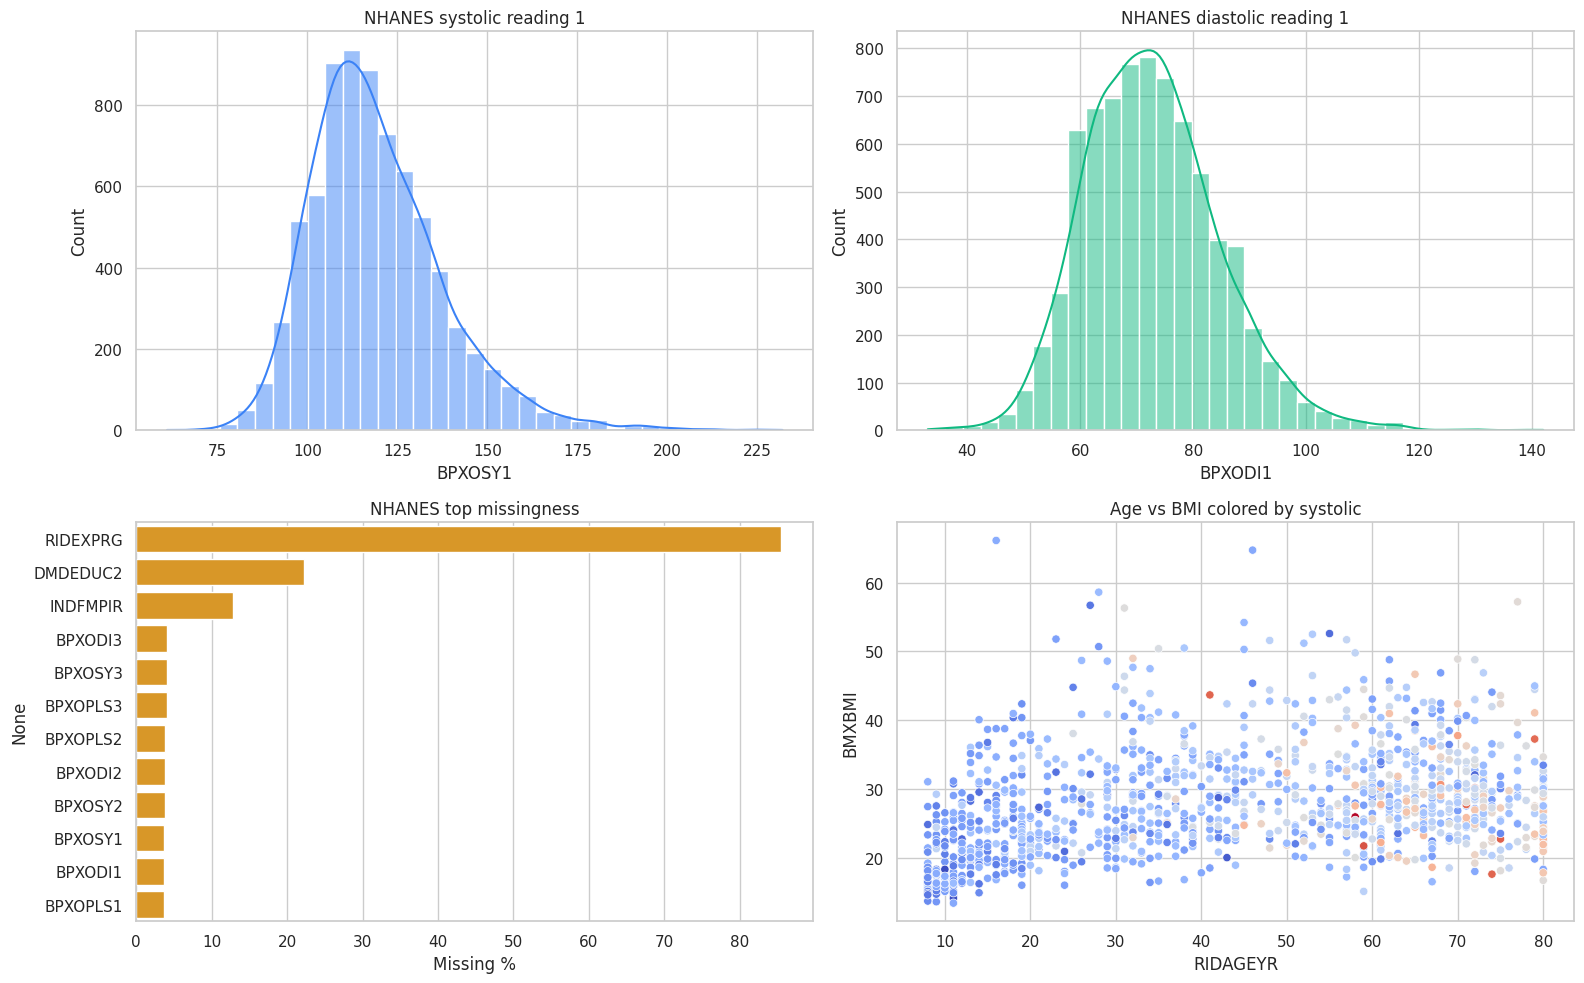

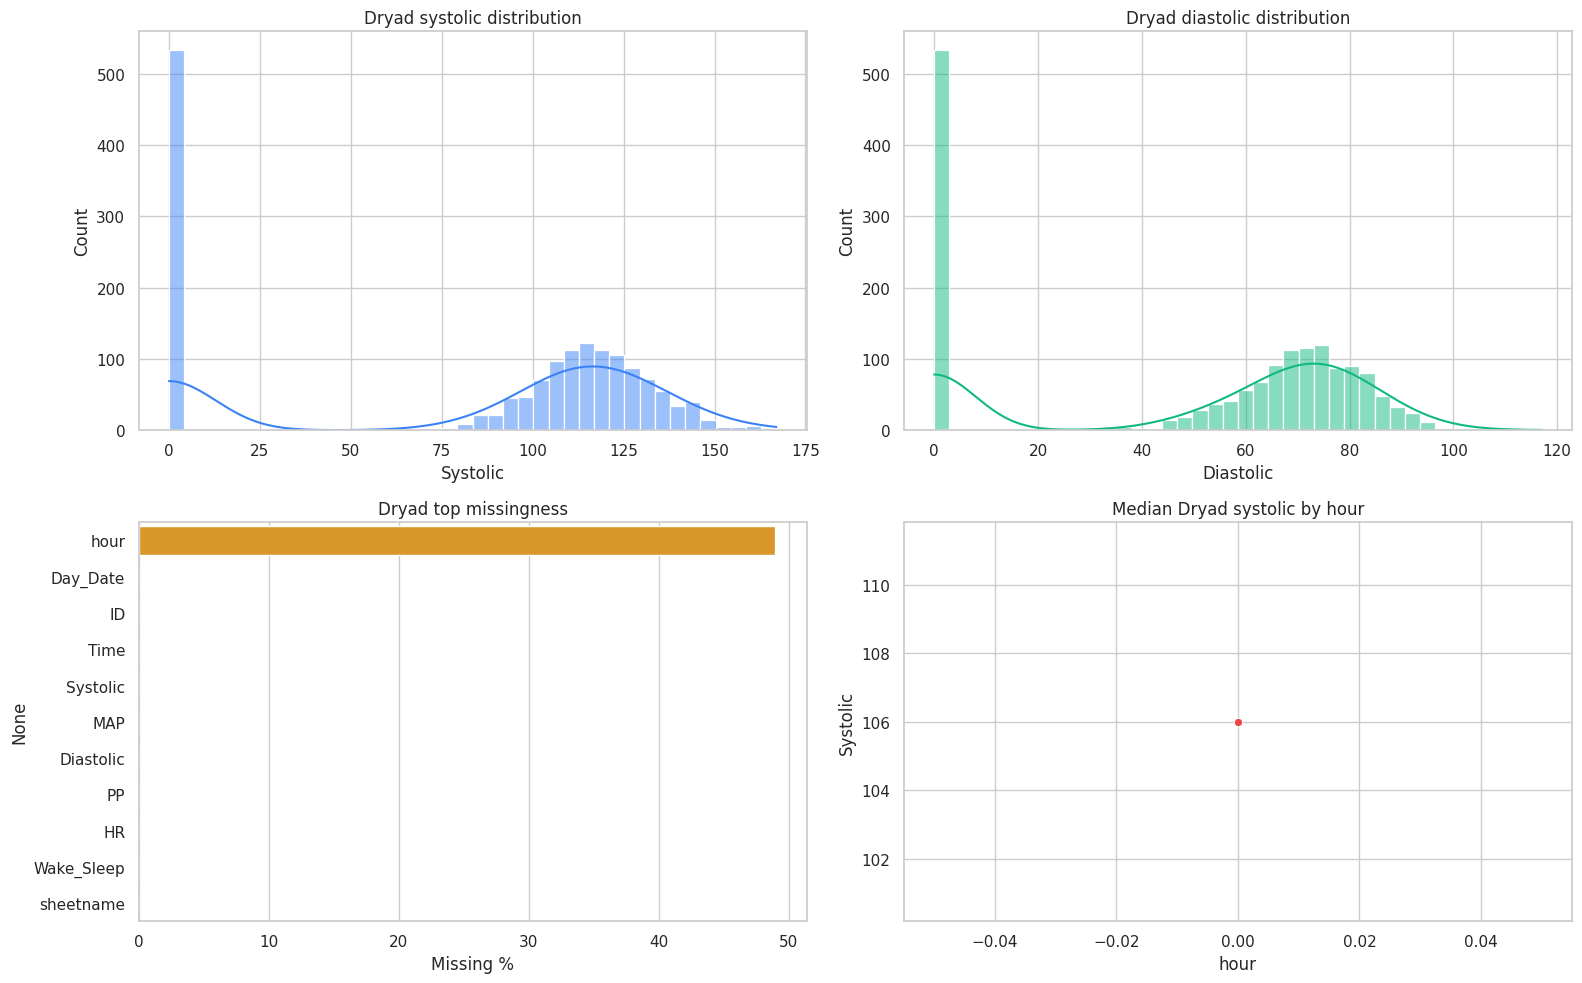

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(df["BPXOSY1"].dropna(), bins=35, kde=True, ax=axes[0, 0], color="#3b82f6")
axes[0, 0].set_title("NHANES systolic reading 1")

sns.histplot(df["BPXODI1"].dropna(), bins=35, kde=True, ax=axes[0, 1], color="#10b981")
axes[0, 1].set_title("NHANES diastolic reading 1")

miss = (df.isna().mean().sort_values(ascending=False).head(12) * 100)
sns.barplot(x=miss.values, y=miss.index, ax=axes[1, 0], color="#f59e0b")
axes[1, 0].set_title("NHANES top missingness")
axes[1, 0].set_xlabel("Missing %")

sample_scatter = df[["RIDAGEYR", "BMXBMI", "BPXOSY1"]].dropna().sample(
    min(1200, df[["RIDAGEYR", "BMXBMI", "BPXOSY1"]].dropna().shape[0]),
    random_state=RANDOM_STATE,
)
sns.scatterplot(
    data=sample_scatter,
    x="RIDAGEYR",
    y="BMXBMI",
    hue="BPXOSY1",
    palette="coolwarm",
    ax=axes[1, 1],
    legend=False,
)
axes[1, 1].set_title("Age vs BMI colored by systolic")

plt.tight_layout()
plt.savefig("output/nhanes_eda.png", dpi=160, bbox_inches="tight")
plt.show()

if df_dryad is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    if sys_col:
        sns.histplot(df_dryad[sys_col].dropna(), bins=40, kde=True, ax=axes[0, 0], color="#3b82f6")
        axes[0, 0].set_title("Dryad systolic distribution")
    else:
        axes[0, 0].axis("off")

    if dia_col:
        sns.histplot(df_dryad[dia_col].dropna(), bins=40, kde=True, ax=axes[0, 1], color="#10b981")
        axes[0, 1].set_title("Dryad diastolic distribution")
    else:
        axes[0, 1].axis("off")

    miss = (df_dryad.isna().mean().sort_values(ascending=False).head(12) * 100)
    sns.barplot(x=miss.values, y=miss.index, ax=axes[1, 0], color="#f59e0b")
    axes[1, 0].set_title("Dryad top missingness")
    axes[1, 0].set_xlabel("Missing %")

    if "hour" in df_dryad.columns and sys_col:
        hourly = df_dryad.groupby("hour")[sys_col].median().reset_index()
        sns.lineplot(data=hourly, x="hour", y=sys_col, marker="o", ax=axes[1, 1], color="#ef4444")
        axes[1, 1].set_title("Median Dryad systolic by hour")
    else:
        axes[1, 1].axis("off")

    plt.tight_layout()
    plt.savefig("output/dryad_eda.png", dpi=160, bbox_inches="tight")
    plt.show()

    if dryad_subject is not None and not dryad_subject.empty:
        dryad_3d = dryad_subject.dropna().copy()
        if not dryad_3d.empty:
            fig = px.scatter_3d(
                dryad_3d.sample(min(len(dryad_3d), 1000), random_state=RANDOM_STATE),
                x="dryadsysmean",
                y="dryadsysstd",
                z="dryadsysrange",
                color="dryadn",
                hover_data=["morningeveningdiff", "dipperratio"],
                title="Dryad subject-level 3D BP variability",
            )
            fig.show()
else:
    print("Dryad EDA skipped because workbook is missing.")

In [40]:
df_model = df.copy()

if "RIDEXPRG" in df_model.columns:
    preg_mask = df_model["RIDEXPRG"].fillna(0) != 1
else:
    preg_mask = pd.Series(True, index=df_model.index)

required_cols = [
    "BPXOSY1", "BPXOSY2", "BPXOSY3",
    "BPXODI1", "BPXODI2", "BPXODI3",
    "BPXOPLS1", "BPXOPLS2", "BPXOPLS3",
    "RIDAGEYR",
]

mask = preg_mask.copy() & (df_model["RIDAGEYR"] >= 18)
for c in required_cols:
    mask &= df_model[c].notna()

df_model = df_model.loc[mask].copy()

# Baseline from first two readings only
df_model["sys12mean"] = df_model[["BPXOSY1", "BPXOSY2"]].mean(axis=1)
df_model["dia12mean"] = df_model[["BPXODI1", "BPXODI2"]].mean(axis=1)
df_model["pulse12mean"] = df_model[["BPXOPLS1", "BPXOPLS2"]].mean(axis=1)

df_model["sys12std"] = df_model[["BPXOSY1", "BPXOSY2"]].std(axis=1).fillna(0)
df_model["dia12std"] = df_model[["BPXODI1", "BPXODI2"]].std(axis=1).fillna(0)
df_model["pulse12std"] = df_model[["BPXOPLS1", "BPXOPLS2"]].std(axis=1).fillna(0)

df_model["systrend21"] = df_model["BPXOSY2"] - df_model["BPXOSY1"]
df_model["diatrend21"] = df_model["BPXODI2"] - df_model["BPXODI1"]
df_model["pulsetrend21"] = df_model["BPXOPLS2"] - df_model["BPXOPLS1"]

df_model["pp12"] = df_model["sys12mean"] - df_model["dia12mean"]
df_model["map12"] = (df_model["sys12mean"] + 2 * df_model["dia12mean"]) / 3

df_model["syscv12"] = (
    df_model["sys12std"] / df_model["sys12mean"].replace(0, np.nan) * 100
).fillna(0)
df_model["diacv12"] = (
    df_model["dia12std"] / df_model["dia12mean"].replace(0, np.nan) * 100
).fillna(0)

df_model["isfemale"] = (df_model["RIAGENDR"] == 2).astype(int)
df_model["lowincomeflag"] = (df_model["INDFMPIR"] < 1.3).fillna(False).astype(int)

df_model["obesitycat"] = pd.cut(
    df_model["BMXBMI"],
    bins=[0, 18.5, 25, 30, 35, 100],
    labels=["Underweight", "Normal", "Overweight", "ObeseI", "ObeseII"],
)

# Dryad-informed proxy features
age_med = df_model["RIDAGEYR"].median()
age_sd = df_model["RIDAGEYR"].std() + 1e-9
bmi_med = df_model["BMXBMI"].median()
bmi_sd = df_model["BMXBMI"].std() + 1e-9
std_med = df_model["sys12std"].median()
std_sd = df_model["sys12std"].std() + 1e-9

df_model["agez"] = (df_model["RIDAGEYR"].fillna(age_med) - age_med) / age_sd
df_model["bmiz"] = (df_model["BMXBMI"].fillna(bmi_med) - bmi_med) / bmi_sd
df_model["sys12stdz"] = (df_model["sys12std"].fillna(std_med) - std_med) / std_sd

df_model["morningsurgeproxy"] = (
    DRYAD_STATS["meanmorningeveningdiff"]
    + 0.40 * df_model["agez"].clip(-3, 3)
    + 0.30 * df_model["bmiz"].clip(-3, 3)
    + 0.30 * df_model["sys12stdz"].clip(-3, 3)
)

df_model["nondipperrisk"] = (
    0.35 * (df_model["sys12mean"] >= 130).astype(int)
    + 0.25 * (df_model["dia12mean"] >= 80).astype(int)
    + 0.20 * (df_model["RIDRETH3"] == 4).fillna(False).astype(int)
    + 0.10 * df_model["agez"].clip(-3, 3)
    + 0.10 * (1 - df_model["antihypertensiveflag"])
)

df_model["circadiandysregulationindex"] = (
    0.5 * df_model["syscv12"]
    + 0.3 * df_model["diacv12"]
    + 0.2 * df_model["nondipperrisk"]
)

SYS_FLOOR = max(5.0, DRYAD_STATS["meansysstd"] * 0.35)
DIA_FLOOR = 4.0

def make_personalized_alert_type(row):
    sbp3 = row["BPXOSY3"]
    dbp3 = row["BPXODI3"]

    sys_scale = max(row["sys12std"], SYS_FLOOR)
    dia_scale = max(row["dia12std"], DIA_FLOOR)

    z_sys = (sbp3 - row["sys12mean"]) / (sys_scale + 1e-9)
    z_dia = (dbp3 - row["dia12mean"]) / (dia_scale + 1e-9)

    if (
        (sbp3 < 90) or (dbp3 < 60) or
        (((sbp3 < 100) or (dbp3 < 65)) and ((z_sys <= -1.0) or (z_dia <= -1.0)))
    ):
        return "Hypotensive"

    if (
        (sbp3 >= 140) or (dbp3 >= 90) or
        (((sbp3 >= 130) or (dbp3 >= 80)) and ((z_sys >= 1.0) or (z_dia >= 1.0)))
    ):
        return "Hypertensive"

    return "Normal"

df_model["alerttype"] = df_model.apply(make_personalized_alert_type, axis=1)
df_model["alerttype"] = pd.Categorical(df_model["alerttype"], categories=CLASS_ORDER, ordered=True)
df_model["alerttypeid"] = df_model["alerttype"].map(CLASS_TO_ID).astype(int)

print("Model dataframe shape:", df_model.shape)
print(df_model["alerttype"].value_counts(dropna=False))
display(df_model.head())

Model dataframe shape: (6061, 45)
alerttype
Normal          4242
Hypertensive    1230
Hypotensive      589
Name: count, dtype: int64


,SEQN,BPXOSY1,BPXOSY2,BPXOSY3,BPXODI1,BPXODI2,BPXODI3,BPXOPLS1,BPXOPLS2,BPXOPLS3,...,lowincomeflag,obesitycat,agez,bmiz,sys12stdz,morningsurgeproxy,nondipperrisk,circadiandysregulationindex,alerttype,alerttypeid
0,130378.0,135.0,131.0,132.0,98.0,96.0,94.0,82.0,79.0,82.0,...,0,Overweight,-0.716148,-0.180939,0.000000,4.659259,0.628385,1.626381,Hypertensive,2
1,130379.0,121.0,117.0,113.0,84.0,76.0,76.0,72.0,71.0,73.0,...,0,ObeseI,0.550883,0.723756,0.000000,5.437480,0.405088,3.390753,Normal,1
2,130380.0,111.0,112.0,104.0,79.0,80.0,76.0,84.0,83.0,77.0,...,0,Overweight,-0.661059,0.194857,-0.661968,4.595443,0.033894,0.590700,Normal,1
3,130386.0,110.0,120.0,115.0,72.0,74.0,75.0,59.0,64.0,64.0,...,0,ObeseI,-1.211942,0.264449,1.323936,4.991739,-0.021194,3.651322,Normal,1
4,130387.0,143.0,136.0,145.0,76.0,74.0,78.0,80.0,80.0,77.0,...,0,ObeseII,0.661059,1.990328,0.661968,6.060112,0.516106,2.443010,Hypertensive,2


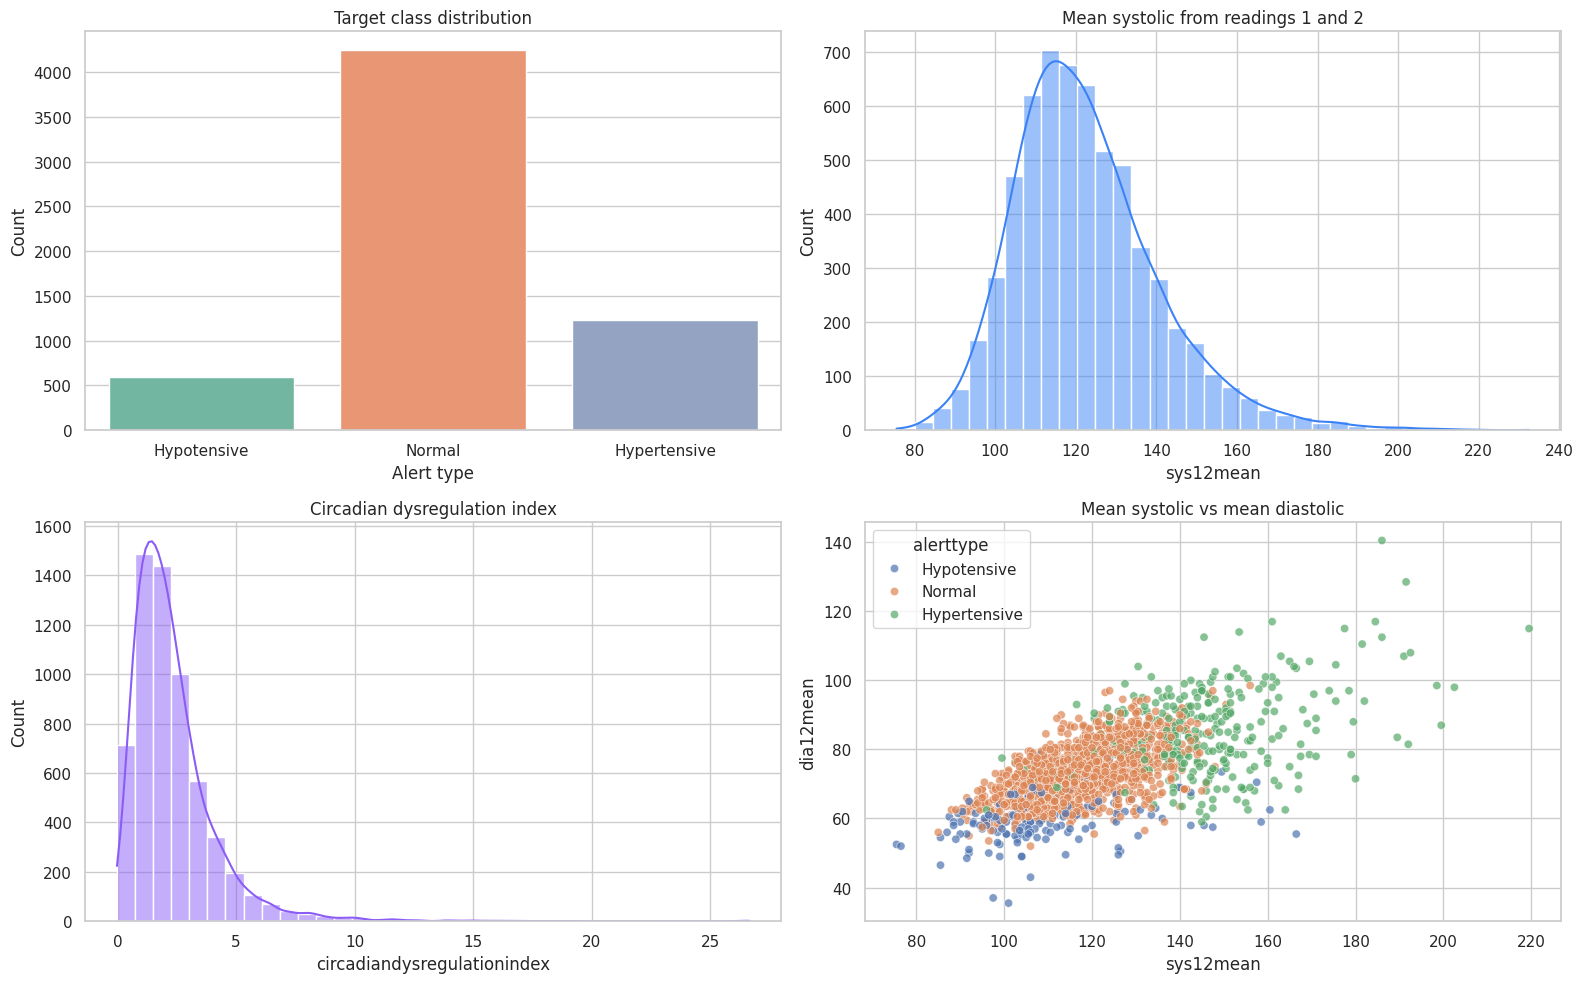

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

class_counts = df_model["alerttype"].value_counts().reindex(CLASS_ORDER)
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Target class distribution")
axes[0, 0].set_xlabel("Alert type")
axes[0, 0].set_ylabel("Count")

sns.histplot(df_model["sys12mean"], bins=35, kde=True, ax=axes[0, 1], color="#3b82f6")
axes[0, 1].set_title("Mean systolic from readings 1 and 2")

sns.histplot(df_model["circadiandysregulationindex"], bins=35, kde=True, ax=axes[1, 0], color="#8b5cf6")
axes[1, 0].set_title("Circadian dysregulation index")

sample = df_model[["sys12mean", "dia12mean", "alerttype"]].dropna().sample(
    min(1500, df_model[["sys12mean", "dia12mean", "alerttype"]].dropna().shape[0]),
    random_state=RANDOM_STATE,
)
sns.scatterplot(data=sample, x="sys12mean", y="dia12mean", hue="alerttype", ax=axes[1, 1], alpha=0.7)
axes[1, 1].set_title("Mean systolic vs mean diastolic")

plt.tight_layout()
plt.savefig("output/model_eda.png", dpi=160, bbox_inches="tight")
plt.show()

plot_df = df_model[["sys12mean", "dia12mean", "circadiandysregulationindex", "alerttype"]].dropna()
fig = px.scatter_3d(
    plot_df.sample(min(len(plot_df), 2000), random_state=RANDOM_STATE),
    x="sys12mean",
    y="dia12mean",
    z="circadiandysregulationindex",
    color="alerttype",
    title="3D view of personalized alert types",
)
fig.show()

In [42]:
feature_cols = [
    "RIDAGEYR", "isfemale", "RIDRETH3", "INDFMPIR", "DMDEDUC2",
    "BMXBMI", "BMXWT", "BMXHT",
    "rxcount", "antihypertensiveflag",
    "BPXOSY1", "BPXOSY2", "BPXODI1", "BPXODI2", "BPXOPLS1", "BPXOPLS2",
    "sys12mean", "dia12mean", "pulse12mean",
    "sys12std", "dia12std", "pulse12std",
    "systrend21", "diatrend21", "pulsetrend21",
    "pp12", "map12", "syscv12", "diacv12",
    "lowincomeflag", "obesitycat",
    "morningsurgeproxy", "nondipperrisk", "circadiandysregulationindex",
]

feature_cols = [c for c in feature_cols if c in df_model.columns]

X = df_model[feature_cols].copy()
y = df_model["alerttypeid"].astype(int).copy()

nunique = X.nunique(dropna=False)
drop_cols = nunique[nunique <= 1].index.tolist()
X = X.drop(columns=drop_cols)

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Class distribution in full data:")
print(pd.Series(y.map(ID_TO_CLASS)).value_counts())
print("Dropped constant columns:", drop_cols)

Train shape: (4848, 33)
Test shape: (1213, 33)
Class distribution in full data:
alerttypeid
Normal          4242
Hypertensive    1230
Hypotensive      589
Name: count, dtype: int64
Dropped constant columns: ['antihypertensiveflag']


In [43]:
class_counts = pd.Series(y_train).value_counts().sort_index()
class_weights = class_counts.max() / class_counts
sample_weight_train = pd.Series(y_train).map(class_weights).values

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=4000,
        class_weight="balanced",
        multi_class="multinomial",
        random_state=RANDOM_STATE,
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.04,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=3,
        reg_alpha=0.2,
        reg_lambda=1.0,
        objective="multi:softprob",
        num_class=len(CLASS_ORDER),
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name, model in models.items():
    pipe = Pipeline([
        ("prep", make_preprocessor(numeric_cols, categorical_cols)),
        ("model", model),
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "balancedaccuracy": "balanced_accuracy",
            "f1macro": "f1_macro",
            "f1weighted": "f1_weighted",
            "precisionmacro": "precision_macro",
            "recallmacro": "recall_macro",
        },
        n_jobs=-1,
    )

    cv_rows.append({
        "model": name,
        "cvaccuracy": scores["test_accuracy"].mean(),
        "cvbalancedaccuracy": scores["test_balancedaccuracy"].mean(),
        "cvmacrof1": scores["test_f1macro"].mean(),
        "cvweightedf1": scores["test_f1weighted"].mean(),
        "cvmacroprecision": scores["test_precisionmacro"].mean(),
        "cvmacrorecall": scores["test_recallmacro"].mean(),
    })

cvdf = pd.DataFrame(cv_rows).sort_values(
    ["cvmacrof1", "cvbalancedaccuracy"], ascending=False
).reset_index(drop=True)

display(cvdf)

,model,cvaccuracy,cvbalancedaccuracy,cvmacrof1,cvweightedf1,cvmacroprecision,cvmacrorecall
0,RandomForest,0.865305,0.772455,0.790704,0.862800,0.815355,0.772455
1,ExtraTrees,0.864068,0.765554,0.787577,0.860965,0.819032,0.765554
2,XGBoost,0.862007,0.740012,0.776565,0.856282,0.831901,0.740012
3,LogisticRegression,0.743607,0.782847,0.686132,0.759580,0.653797,0.782847


,model,accuracy,balancedaccuracy,macrof1,weightedf1,mcc,macroprecision,macrorecall,recallhypotensive,specificityhypotensive,recallnormal,specificitynormal,recallhypertensive,specificityhypertensive,rocaucovrmacro
0,ExtraTrees,0.849959,0.765811,0.782005,0.847867,0.664668,0.800611,0.765811,0.661017,0.975342,0.912839,0.714286,0.723577,0.947260,0.925888
1,RandomForest,0.849134,0.764911,0.780848,0.847146,0.663243,0.799220,0.764911,0.652542,0.975342,0.910483,0.714286,0.731707,0.946225,0.926854
2,XGBoost,0.826876,0.778073,0.762503,0.828817,0.633834,0.748965,0.778073,0.711864,0.955251,0.862191,0.752747,0.760163,0.926577,0.923890
3,LogisticRegression,0.725474,0.789467,0.675717,0.742162,0.543374,0.643906,0.789467,0.872881,0.854795,0.678445,0.862637,0.817073,0.871768,0.912142


Best supervised model: ExtraTrees

ExtraTrees


,class,support,precision,recall,specificity
0,Hypotensive,118,0.742857,0.661017,0.975342
1,Normal,849,0.881684,0.912839,0.714286
2,Hypertensive,246,0.777293,0.723577,0.947260


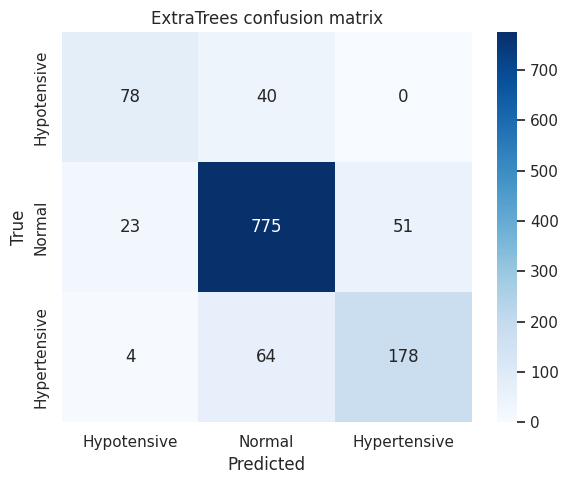


RandomForest


,class,support,precision,recall,specificity
0,Hypotensive,118,0.740385,0.652542,0.975342
1,Normal,849,0.881414,0.910483,0.714286
2,Hypertensive,246,0.775862,0.731707,0.946225


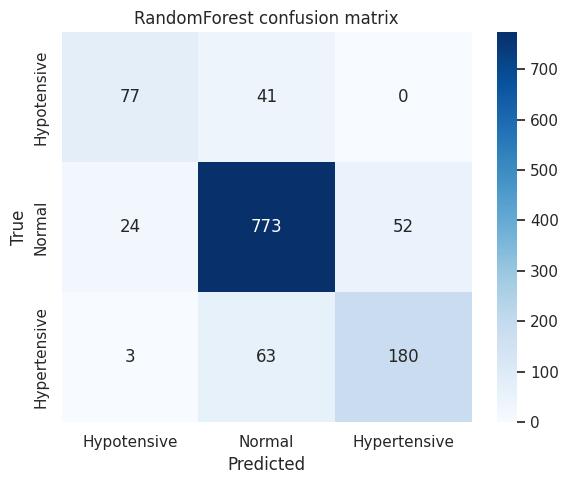


XGBoost


,class,support,precision,recall,specificity
0,Hypotensive,118,0.631579,0.711864,0.955251
1,Normal,849,0.890511,0.862191,0.752747
2,Hypertensive,246,0.724806,0.760163,0.926577


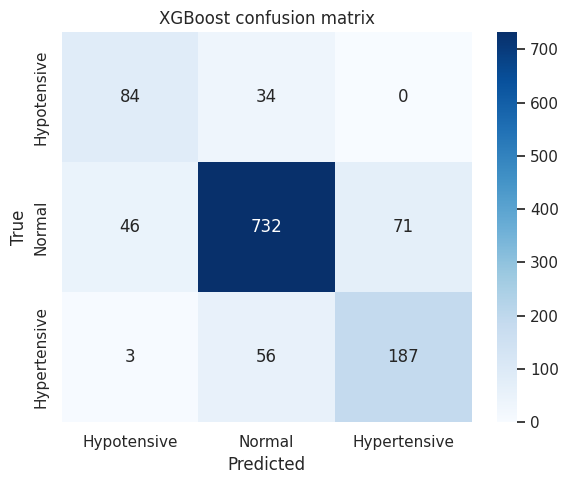


LogisticRegression


,class,support,precision,recall,specificity
0,Hypotensive,118,0.393130,0.872881,0.854795
1,Normal,849,0.920128,0.678445,0.862637
2,Hypertensive,246,0.618462,0.817073,0.871768


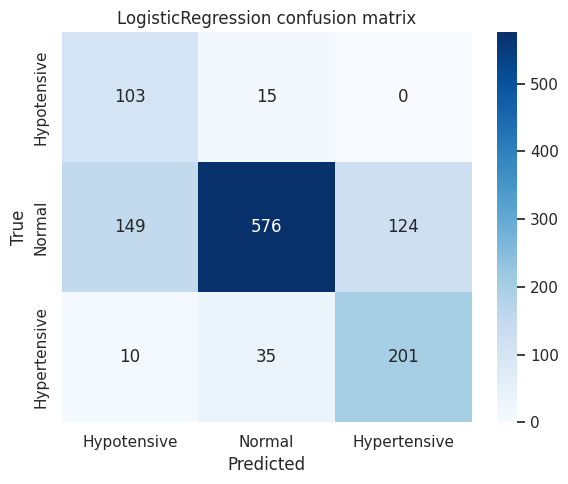

In [44]:
results = []
per_class_tables = {}
conf_mats = {}
fitted_artifacts = {}

for name, model in models.items():
    prep = make_preprocessor(numeric_cols, categorical_cols)

    if name == "XGBoost":
        X_train_prepared = prep.fit_transform(X_train)
        X_test_prepared = prep.transform(X_test)

        model.fit(X_train_prepared, y_train, sample_weight=sample_weight_train)
        y_pred = model.predict(X_test_prepared)
        y_prob = model.predict_proba(X_test_prepared)

        fitted_artifacts[name] = {
            "type": "xgbmanual",
            "model": model,
            "prep": prep,
        }
    else:
        pipe = Pipeline([
            ("prep", prep),
            ("model", model),
        ])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)

        fitted_artifacts[name] = {
            "type": "pipeline",
            "obj": pipe,
        }

    metrics, cm, per_class_df = evaluate_multiclass(
        name, y_test, y_pred, y_prob=y_prob, class_order=CLASS_ORDER
    )

    results.append(metrics)
    per_class_tables[name] = per_class_df
    conf_mats[name] = cm

resultsdf = pd.DataFrame(results).sort_values(
    ["macrof1", "balancedaccuracy"], ascending=False
).reset_index(drop=True)

display(resultsdf)

best_model_name = resultsdf.iloc[0]["model"]
print("Best supervised model:", best_model_name)

for model_name in resultsdf["model"]:
    print(f"\n{model_name}")
    display(per_class_tables[model_name])
    plot_cm(conf_mats[model_name], CLASS_ORDER, f"{model_name} confusion matrix")

,model,accuracy,balancedaccuracy,macrof1,weightedf1,mcc,macroprecision,macrorecall,recallhypotensive,specificityhypotensive,recallnormal,specificitynormal,recallhypertensive,specificityhypertensive,rocaucovrmacro
0,SecondReadingRules,0.699918,0.73614,0.678372,0.714863,0.506215,0.692715,0.73614,0.635593,0.973516,0.641932,0.843407,0.930894,0.712513,0.789642


,model,accuracy,balancedaccuracy,macrof1,weightedf1,mcc,macroprecision,macrorecall,recallhypotensive,specificityhypotensive,recallnormal,specificitynormal,recallhypertensive,specificityhypertensive,rocaucovrmacro
0,IsolationForestSplit,0.692498,0.578098,0.575698,0.692947,0.333380,0.573498,0.578098,0.466102,0.936986,0.784452,0.505495,0.483740,0.871768,NaN
1,KMeans3,0.727123,0.546468,0.487321,0.696557,0.415822,0.451149,0.546468,0.000000,1.000000,0.793875,0.582418,0.845528,0.814891,NaN


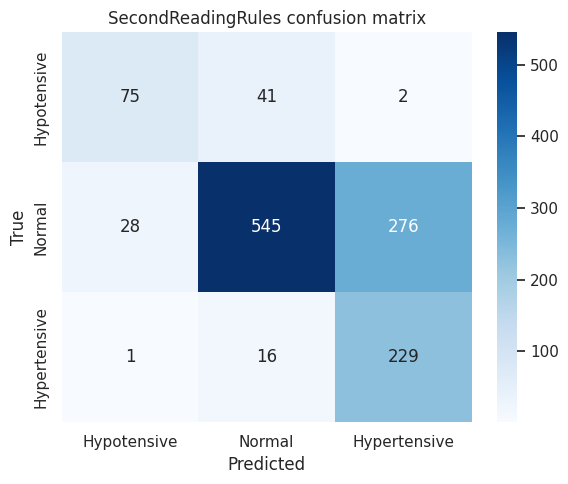

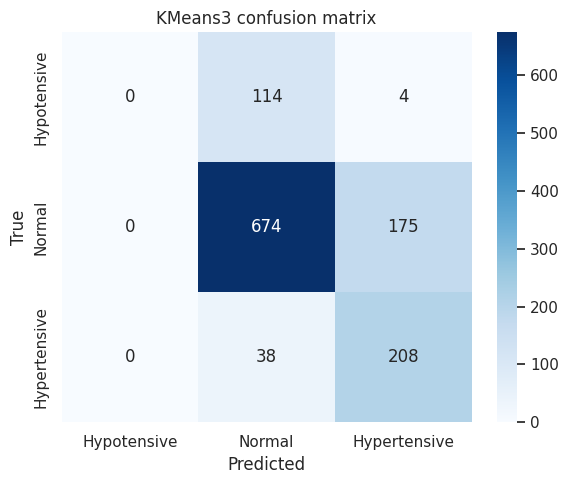

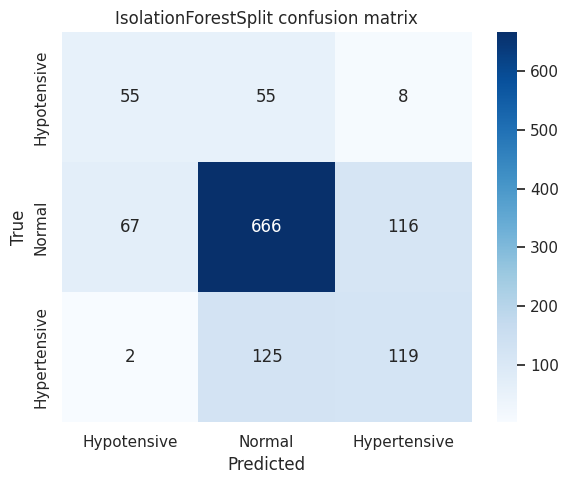

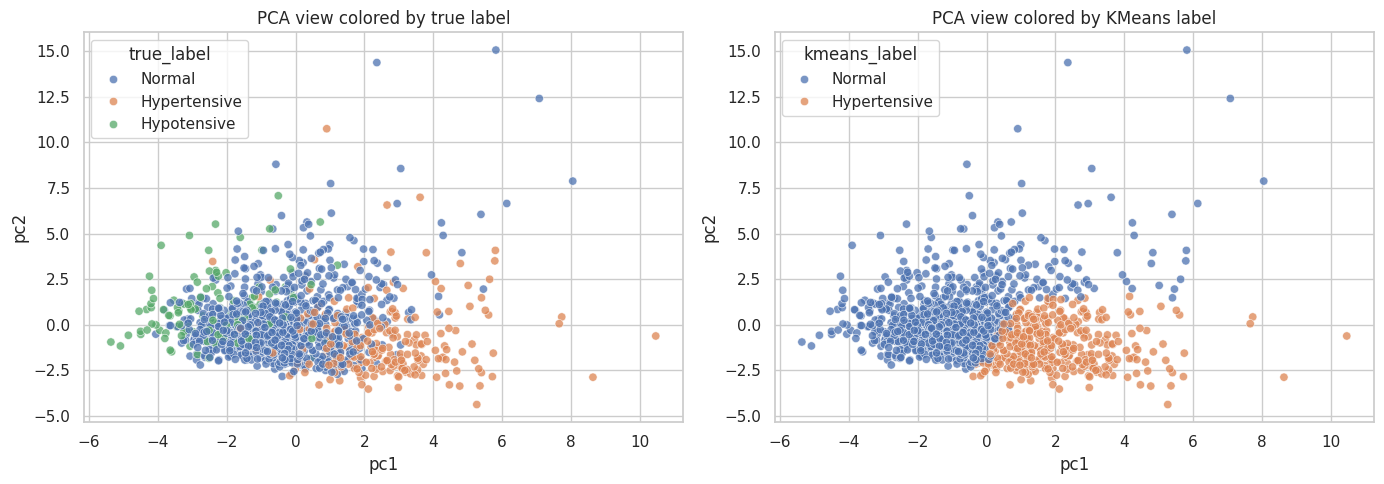

,model,accuracy,balancedaccuracy,macrof1,weightedf1,mcc,macroprecision,macrorecall,recallhypotensive,specificityhypotensive,recallnormal,specificitynormal,recallhypertensive,specificityhypertensive,rocaucovrmacro,group
0,ExtraTrees,0.849959,0.765811,0.782005,0.847867,0.664668,0.800611,0.765811,0.661017,0.975342,0.912839,0.714286,0.723577,0.947260,0.925888,supervised
1,RandomForest,0.849134,0.764911,0.780848,0.847146,0.663243,0.799220,0.764911,0.652542,0.975342,0.910483,0.714286,0.731707,0.946225,0.926854,supervised
2,XGBoost,0.826876,0.778073,0.762503,0.828817,0.633834,0.748965,0.778073,0.711864,0.955251,0.862191,0.752747,0.760163,0.926577,0.923890,supervised
3,LogisticRegression,0.725474,0.789467,0.675717,0.742162,0.543374,0.643906,0.789467,0.872881,0.854795,0.678445,0.862637,0.817073,0.871768,0.912142,supervised
4,SecondReadingRules,0.699918,0.736140,0.678372,0.714863,0.506215,0.692715,0.736140,0.635593,0.973516,0.641932,0.843407,0.930894,0.712513,0.789642,rulebased
5,IsolationForestSplit,0.692498,0.578098,0.575698,0.692947,0.333380,0.573498,0.578098,0.466102,0.936986,0.784452,0.505495,0.483740,0.871768,NaN,unsupervised
6,KMeans3,0.727123,0.546468,0.487321,0.696557,0.415822,0.451149,0.546468,0.000000,1.000000,0.793875,0.582418,0.845528,0.814891,NaN,unsupervised


In [45]:
# Rule-based baseline from second reading only
rule_pred_labels = X_test.apply(
    lambda row: second_reading_rules_bp(row["BPXOSY2"], row["BPXODI2"]), axis=1
)
rule_pred = rule_pred_labels.map(CLASS_TO_ID).values
rule_prob = np.eye(len(CLASS_ORDER))[rule_pred]

rule_metrics, rule_cm, rule_per_class = evaluate_multiclass(
    "SecondReadingRules", y_test, rule_pred, y_prob=rule_prob, class_order=CLASS_ORDER
)

# Unsupervised baseline 1: KMeans
unsup_prep = make_preprocessor(numeric_cols, categorical_cols)
X_train_unsup = unsup_prep.fit_transform(X_train)
X_test_unsup = unsup_prep.transform(X_test)

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=20)
train_clusters = kmeans.fit_predict(X_train_unsup)
test_clusters = kmeans.predict(X_test_unsup)

cluster_to_class = {}
for cl in np.unique(train_clusters):
    idx = np.where(train_clusters == cl)[0]
    majority_class = pd.Series(y_train.iloc[idx]).value_counts().idxmax()
    cluster_to_class[cl] = majority_class

kmeans_pred = np.array([cluster_to_class.get(c, CLASS_TO_ID["Normal"]) for c in test_clusters])

kmeans_metrics, kmeans_cm, kmeans_per_class = evaluate_multiclass(
    "KMeans3", y_test, kmeans_pred, y_prob=None, class_order=CLASS_ORDER
)

# Unsupervised baseline 2: IsolationForest + low/high split
non_normal_rate = 1 - (y_train == CLASS_TO_ID["Normal"]).mean()
contamination = float(np.clip(non_normal_rate, 0.05, 0.45))

iso = IsolationForest(
    n_estimators=400,
    contamination=contamination,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iso.fit(X_train_unsup)

train_sys_median = X_train["sys12mean"].median()
train_dia_median = X_train["dia12mean"].median()

iso_flags = iso.predict(X_test_unsup)  # 1 normal, -1 anomaly
iso_pred_labels = []
for flag, (_, row) in zip(iso_flags, X_test.iterrows()):
    if flag == 1:
        iso_pred_labels.append("Normal")
    else:
        if (row["sys12mean"] < train_sys_median) and (row["dia12mean"] < train_dia_median):
            iso_pred_labels.append("Hypotensive")
        else:
            iso_pred_labels.append("Hypertensive")

iso_pred = pd.Series(iso_pred_labels).map(CLASS_TO_ID).values

iso_metrics, iso_cm, iso_per_class = evaluate_multiclass(
    "IsolationForestSplit", y_test, iso_pred, y_prob=None, class_order=CLASS_ORDER
)

unsup_resultsdf = pd.DataFrame([kmeans_metrics, iso_metrics]).sort_values(
    ["macrof1", "balancedaccuracy"], ascending=False
).reset_index(drop=True)

display(pd.DataFrame([rule_metrics]))
display(unsup_resultsdf)

plot_cm(rule_cm, CLASS_ORDER, "SecondReadingRules confusion matrix")
plot_cm(kmeans_cm, CLASS_ORDER, "KMeans3 confusion matrix")
plot_cm(iso_cm, CLASS_ORDER, "IsolationForestSplit confusion matrix")

# PCA visualization for unsupervised structure
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_test_pca = pca.fit_transform(X_test_unsup)
pca_df = pd.DataFrame({
    "pc1": X_test_pca[:, 0],
    "pc2": X_test_pca[:, 1],
    "true_label": pd.Series(y_test).map(ID_TO_CLASS).values,
    "kmeans_label": pd.Series(kmeans_pred).map(ID_TO_CLASS).values,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=pca_df, x="pc1", y="pc2", hue="true_label", ax=axes[0], alpha=0.75)
axes[0].set_title("PCA view colored by true label")
sns.scatterplot(data=pca_df, x="pc1", y="pc2", hue="kmeans_label", ax=axes[1], alpha=0.75)
axes[1].set_title("PCA view colored by KMeans label")
plt.tight_layout()
plt.savefig("output/unsupervised_pca.png", dpi=160, bbox_inches="tight")
plt.show()

allcompare = pd.concat(
    [
        resultsdf.assign(group="supervised"),
        pd.DataFrame([rule_metrics]).assign(group="rulebased"),
        unsup_resultsdf.assign(group="unsupervised"),
    ],
    ignore_index=True,
)
display(allcompare)

,feature,importance_mean,importance_std
0,dia12mean,0.047677,0.006669
1,BPXODI2,0.043433,0.008241
2,map12,0.034532,0.008974
3,BPXODI1,0.031778,0.005571
4,sys12mean,0.011128,0.003898
5,isfemale,0.004204,0.002456
6,pulse12std,0.003684,0.001345
7,BMXHT,0.002984,0.001209
8,BPXOSY2,0.002935,0.003369
9,pp12,0.002917,0.005539


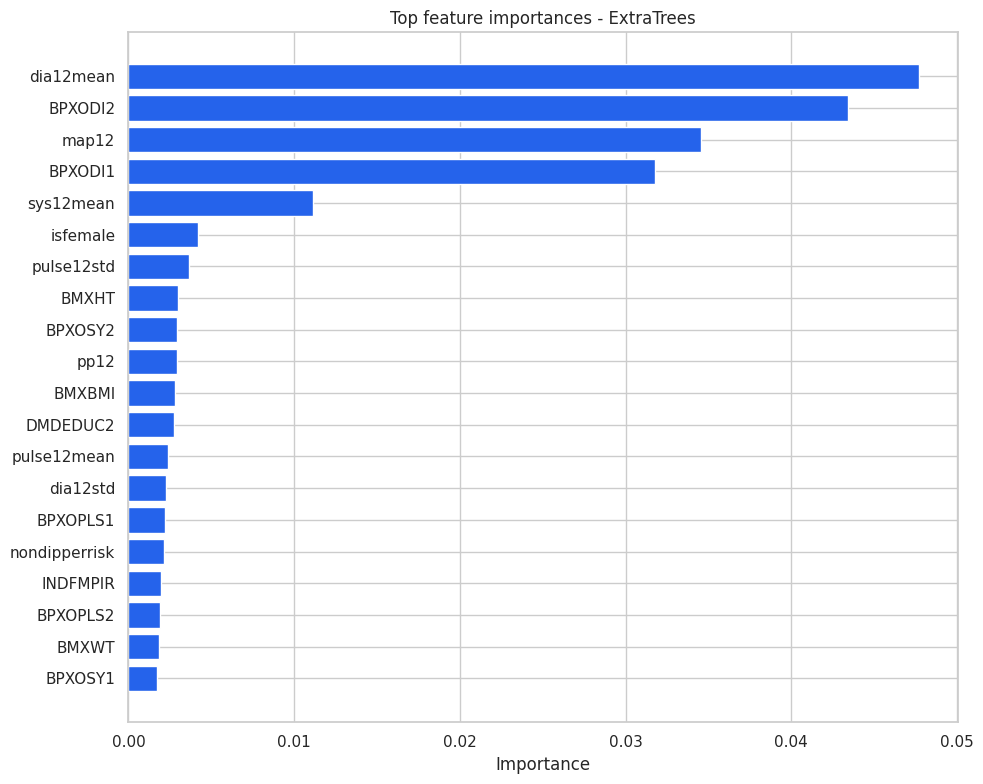

In [46]:
final_artifact = fitted_artifacts[best_model_name]

if final_artifact["type"] == "pipeline":
    final_pipe = final_artifact["obj"]
    pi = permutation_importance(
        final_pipe,
        X_test,
        y_test,
        scoring="f1_macro",
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    fi_df = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": pi.importances_mean,
        "importance_std": pi.importances_std,
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)
else:
    final_model = final_artifact["model"]
    final_prep = final_artifact["prep"]
    transformed_names = final_prep.get_feature_names_out()
    fi_df = pd.DataFrame({
        "feature": transformed_names,
        "importance_mean": final_model.feature_importances_,
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

display(fi_df.head(20))

top_fi = fi_df.head(20).iloc[::-1]
plt.figure(figsize=(10, 8))
plt.barh(top_fi["feature"], top_fi["importance_mean"], color="#2563eb")
plt.title(f"Top feature importances - {best_model_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("output/feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()

bundle = {
    "best_model_name": best_model_name,
    "class_order": CLASS_ORDER,
    "feature_columns": X.columns.tolist(),
    "numeric_columns": numeric_cols,
    "categorical_columns": categorical_cols,
    "age_med": float(age_med),
    "age_sd": float(age_sd),
    "bmi_med": float(bmi_med),
    "bmi_sd": float(bmi_sd),
    "std_med": float(std_med),
    "std_sd": float(std_sd),
    "dryad_stats": DRYAD_STATS,
    "sys_floor": float(SYS_FLOOR),
    "dia_floor": float(DIA_FLOOR),
}

if final_artifact["type"] == "pipeline":
    bundle["artifact_type"] = "pipeline"
    bundle["pipeline"] = final_pipe
else:
    bundle["artifact_type"] = "xgbmanual"
    bundle["model"] = final_model
    bundle["preprocessor"] = final_prep

joblib.dump(bundle, "output/best_model_bundle.joblib")

with open("output/model_metadata.json", "w") as f:
    json.dump(
        {
            k: v for k, v in bundle.items()
            if k not in {"pipeline", "model", "preprocessor"}
        },
        f,
        indent=2,
    )

In [47]:
def build_patient_features(patient: dict) -> pd.DataFrame:
    sys1, sys2 = patient["sys1"], patient["sys2"]
    dia1, dia2 = patient["dias1"], patient["dias2"]
    pulse1, pulse2 = patient["pulse1"], patient["pulse2"]

    sys12mean = np.mean([sys1, sys2])
    dia12mean = np.mean([dia1, dia2])
    pulse12mean = np.mean([pulse1, pulse2])

    sys12std = np.std([sys1, sys2], ddof=1 if len([sys1, sys2]) > 1 else 0)
    dia12std = np.std([dia1, dia2], ddof=1 if len([dia1, dia2]) > 1 else 0)
    pulse12std = np.std([pulse1, pulse2], ddof=1 if len([pulse1, pulse2]) > 1 else 0)

    agez = (patient.get("age", age_med) - age_med) / age_sd
    bmiz = (patient.get("bmi", bmi_med) - bmi_med) / bmi_sd
    stdz = (sys12std - std_med) / std_sd

    row = {
        "RIDAGEYR": patient.get("age", age_med),
        "isfemale": int(str(patient.get("gender", "M")).upper() == "F"),
        "RIDRETH3": patient.get("racecode", 3),
        "INDFMPIR": patient.get("incomepir", 1.5),
        "DMDEDUC2": patient.get("education", 3),
        "BMXBMI": patient.get("bmi", bmi_med),
        "BMXWT": patient.get("weight", np.nan),
        "BMXHT": patient.get("height", np.nan),
        "rxcount": patient.get("rxcount", 0),
        "antihypertensiveflag": int(patient.get("onrecentrx", 0)),
        "BPXOSY1": sys1,
        "BPXOSY2": sys2,
        "BPXODI1": dia1,
        "BPXODI2": dia2,
        "BPXOPLS1": pulse1,
        "BPXOPLS2": pulse2,
        "sys12mean": sys12mean,
        "dia12mean": dia12mean,
        "pulse12mean": pulse12mean,
        "sys12std": sys12std,
        "dia12std": dia12std,
        "pulse12std": pulse12std,
        "systrend21": sys2 - sys1,
        "diatrend21": dia2 - dia1,
        "pulsetrend21": pulse2 - pulse1,
        "pp12": sys12mean - dia12mean,
        "map12": (sys12mean + 2 * dia12mean) / 3,
        "syscv12": (sys12std / sys12mean * 100) if sys12mean else 0,
        "diacv12": (dia12std / dia12mean * 100) if dia12mean else 0,
        "lowincomeflag": int(patient.get("incomepir", 1.5) < 1.3),
        "obesitycat": pd.cut(
            pd.Series([patient.get("bmi", bmi_med)]),
            bins=[0, 18.5, 25, 30, 35, 100],
            labels=["Underweight", "Normal", "Overweight", "ObeseI", "ObeseII"],
        ).astype(str).iloc[0],
    }

    row["morningsurgeproxy"] = (
        DRYAD_STATS["meanmorningeveningdiff"]
        + 0.40 * np.clip(agez, -3, 3)
        + 0.30 * np.clip(bmiz, -3, 3)
        + 0.30 * np.clip(stdz, -3, 3)
    )

    row["nondipperrisk"] = (
        0.35 * int(sys12mean >= 130)
        + 0.25 * int(dia12mean >= 80)
        + 0.20 * int(patient.get("racecode", 3) == 4)
        + 0.10 * np.clip(agez, -3, 3)
        + 0.10 * (1 - int(patient.get("onrecentrx", 0)))
    )

    row["circadiandysregulationindex"] = (
        0.5 * row["syscv12"]
        + 0.3 * row["diacv12"]
        + 0.2 * row["nondipperrisk"]
    )

    out = pd.DataFrame([row])

    for c in X.columns:
        if c not in out.columns:
            out[c] = np.nan

    out = out[X.columns]
    return out


def predict_patient_alert_type(patient: dict):
    xp = build_patient_features(patient)

    if final_artifact["type"] == "xgbmanual":
        xp_prepared = final_artifact["prep"].transform(xp)
        prob = final_artifact["model"].predict_proba(xp_prepared)[0]
    else:
        prob = final_artifact["obj"].predict_proba(xp)[0]

    pred_id = int(np.argmax(prob))
    return {
        "predictedalerttype": ID_TO_CLASS[pred_id],
        "classprobabilities": {
            cls: round(float(prob[i]), 4) for i, cls in enumerate(CLASS_ORDER)
        },
    }


demo_patient = {
    "age": 71,
    "gender": "F",
    "racecode": 4,
    "bmi": 35.8,
    "incomepir": 0.8,
    "education": 2,
    "sys1": 170,
    "sys2": 174,
    "dias1": 102,
    "dias2": 106,
    "pulse1": 84,
    "pulse2": 86,
    "weight": 89,
    "height": 158,
    "onrecentrx": 0,
    "rxcount": 0,
}

predict_patient_alert_type(demo_patient)

{'predictedalerttype': 'Hypertensive',
 'classprobabilities': {'Hypotensive': 0.0,
  'Normal': 0.0044,
  'Hypertensive': 0.9956}}

In [48]:
allcompare.to_csv("output/model_comparison_multiclass.csv", index=False)
resultsdf.to_csv("output/supervised_results_multiclass.csv", index=False)
unsup_resultsdf.to_csv("output/unsupervised_results_multiclass.csv", index=False)
df_model.to_csv("output/nhanes_personalized_alert_dataset.csv", index=False)
cvdf.to_csv("output/cv_results_multiclass.csv", index=False)
fi_df.to_csv("output/feature_importance.csv", index=False)

for model_name, table in per_class_tables.items():
    safe = model_name.lower().replace(" ", "_")
    table.to_csv(f"output/{safe}_perclass_metrics.csv", index=False)

rule_per_class.to_csv("output/secondreadingrules_perclass_metrics.csv", index=False)
kmeans_per_class.to_csv("output/kmeans3_perclass_metrics.csv", index=False)
iso_per_class.to_csv("output/isolationforestsplit_perclass_metrics.csv", index=False)

print("Saved outputs to output/")

Saved outputs to output/
